In [5]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# This is the exact path based on your 'Found folder' output
base_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/'

train_dir = os.path.join(base_path, 'train')
test_dir = os.path.join(base_path, 'test')
val_dir = os.path.join(base_path, 'val')

print(f"Checking path: {train_dir}")
if os.path.exists(train_dir):
    print("✅ Success! The path is correct.")
    print("Folders found:", os.listdir(base_path))
else:
    print("❌ Path still not found. Double check if the dataset is added to the notebook.")

Checking path: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
✅ Success! The path is correct.
Folders found: ['val', '.DS_Store', 'test', 'train']


In [4]:
import os

# This lists everything in the input folder to see the exact name
for dirname, _, filenames in os.walk('/kaggle/input'):
    # We only want to see the main folders, not every single image file
    if 'train' in dirname or 'test' in dirname:
        print(f"Found folder: {dirname}")

# Look at the output of this cell. 
# If it says something like /kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
# (with 'chest_xray' appearing twice), that is our answer!

Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train/NORMAL
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test/PNEUMONIA
Found folder: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test

In [6]:
# Image settings
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# 1. Augment the training data (tilting, zooming, etc.)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# 2. Only rescale test/val data
test_val_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = test_val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [12]:
# new cell 3
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models

# 1. Load the "Expert" brain (DenseNet121)
# We exclude the top layer because we want to add our own "Pneumonia" classifier
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# 2. Freeze the base model (don't change the expert's pre-existing knowledge)
base_model.trainable = False 

# 3. Add our custom "Pneumonia" layers on top
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid') # Final decision
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()] # Recall is critical for medical AI
)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [13]:
# new cell 4
from tensorflow.keras.callbacks import EarlyStopping

# 1. Setup Early Stopping: stops training if the model stops improving for 3 rounds
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

# 2. Start the Training
# DenseNet is powerful, so 10-12 epochs is usually enough to see great results
history = model.fit(
    train_generator,
    epochs=12,
    validation_data=test_generator,
    callbacks=[early_stop]
)

Epoch 1/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 620ms/step - accuracy: 0.8599 - loss: 0.3862 - recall: 0.9121 - val_accuracy: 0.8750 - val_loss: 0.3476 - val_recall: 0.9615
Epoch 2/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 456ms/step - accuracy: 0.9280 - loss: 0.1949 - recall: 0.9536 - val_accuracy: 0.8910 - val_loss: 0.3155 - val_recall: 0.9205
Epoch 3/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 454ms/step - accuracy: 0.9378 - loss: 0.1508 - recall: 0.9537 - val_accuracy: 0.8830 - val_loss: 0.2936 - val_recall: 0.9308
Epoch 4/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 456ms/step - accuracy: 0.9355 - loss: 0.1624 - recall: 0.9540 - val_accuracy: 0.8798 - val_loss: 0.3141 - val_recall: 0.9462
Epoch 5/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 454ms/step - accuracy: 0.9445 - loss: 0.1394 - recall: 0.9643 - val_accuracy: 0.8862 - val_loss: 0.3113 - val_recall: 0.9359
Epoch 6/12
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 449ms/step - accuracy: 0.9472 - loss: 0.1401 - recall: 0.9653 - val_accuracy: 0.8910 - val_loss: 0.2819 - val_

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 924ms/step
UPGRADED Classification Report:
              precision    recall  f1-score   support

      Normal       0.34      0.35      0.34       234
   Pneumonia       0.60      0.60      0.60       390

    accuracy                           0.50       624
   macro avg       0.47      0.47      0.47       624
weighted avg       0.51      0.50      0.51       624



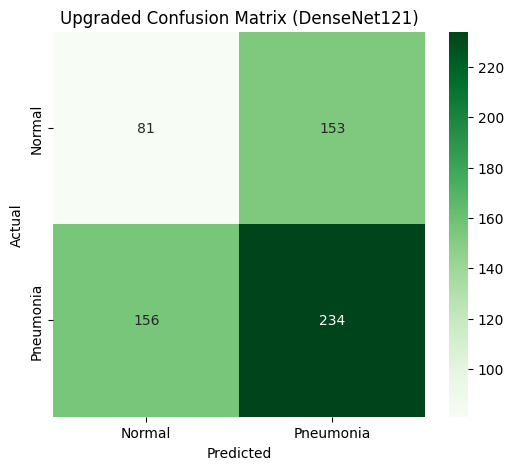

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Get predictions
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)

# 2. Print Classification Report
print("UPGRADED Classification Report:")
print(classification_report(test_generator.classes, y_pred, target_names=['Normal', 'Pneumonia']))

# 3. Visual Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Upgraded Confusion Matrix (DenseNet121)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

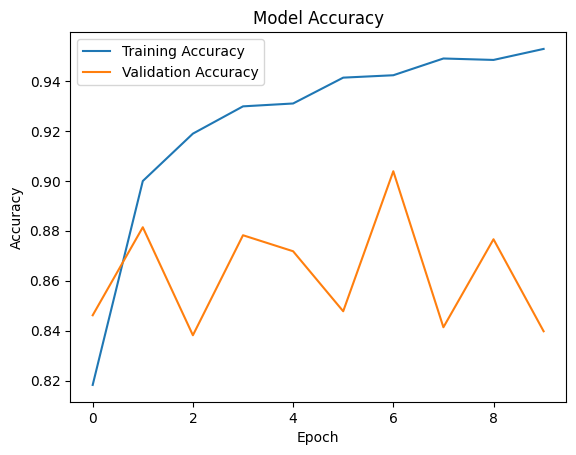

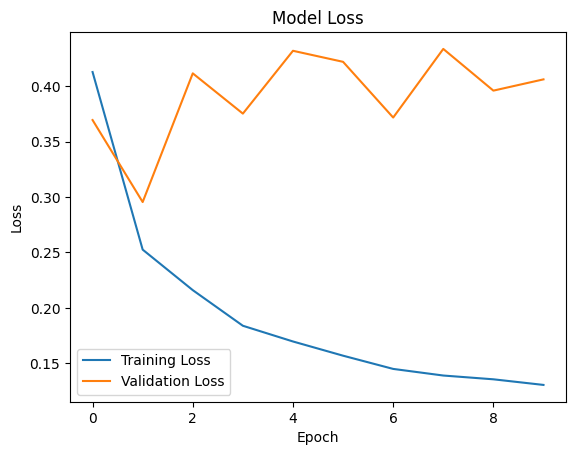

In [9]:
#cell 5
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
Result: PNEUMONIA detected with 83.39% confidence.


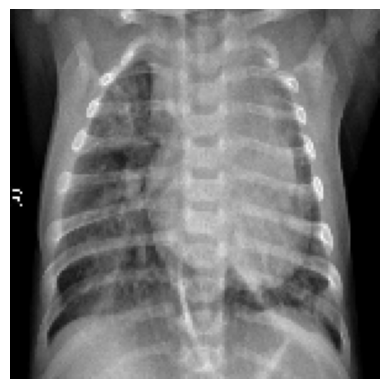

In [10]:
#cell 6
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# --- STEP 1: PICK AN IMAGE ---
# Let's test a PNEUMONIA image first. 
# You can change 'PNEUMONIA' to 'NORMAL' in the path below to test a healthy lung!
test_img_path = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg'

# --- STEP 2: PREPARE THE IMAGE ---
img = image.load_img(test_img_path, target_size=(150, 150))
img_array = image.img_to_array(img) / 255.0  # Normalize pixels
img_array = np.expand_dims(img_array, axis=0) # Reshape for the model

# --- STEP 3: PREDICT ---
prediction = model.predict(img_array)

# --- STEP 4: SHOW THE RESULT ---
plt.imshow(img)
plt.axis('off')

if prediction[0] > 0.5:
    confidence = prediction[0][0] * 100
    print(f"Result: PNEUMONIA detected with {confidence:.2f}% confidence.")
else:
    confidence = (1 - prediction[0][0]) * 100
    print(f"Result: This lung looks NORMAL with {confidence:.2f}% confidence.")

plt.show()

Found 624 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step
REAL UPGRADED Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.86      0.86       234
   Pneumonia       0.92      0.91      0.91       390

    accuracy                           0.89       624
   macro avg       0.88      0.89      0.89       624
weighted avg       0.89      0.89      0.89       624



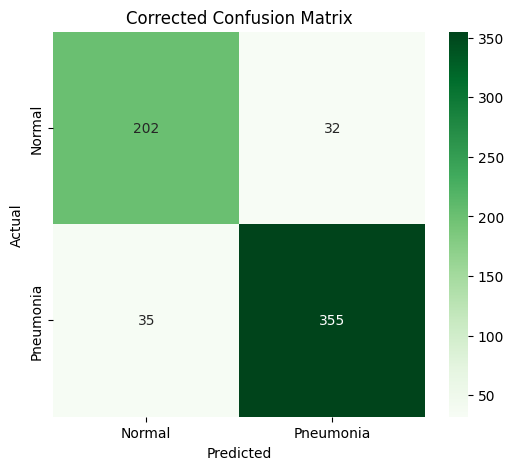

In [15]:
#cell 7
# 1. Re-initialize the test generator correctly so labels aren't mixed up
test_val_datagen = ImageDataGenerator(rescale=1./255)

test_generator_fixed = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # THIS IS THE CRITICAL FIX
)

# 2. Get the real predictions
predictions = model.predict(test_generator_fixed)
y_pred = (predictions > 0.5).astype(int)

# 3. Print the REAL Classification Report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("REAL UPGRADED Classification Report:")
print(classification_report(test_generator_fixed.classes, y_pred, target_names=['Normal', 'Pneumonia']))

# 4. Plot the Matrix
cm = confusion_matrix(test_generator_fixed.classes, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Corrected Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [16]:
#cell 8
# Save the current high-performing model
model.save('medical_ai_v1_89percent.keras')
print("✅ Cell 8 Complete: Model saved as 'medical_ai_v1_89percent.keras'")

✅ Cell 8 Complete: Model saved as 'medical_ai_v1_89percent.keras'


In [17]:
#cell 9
# 1. Unfreeze the DenseNet layers so the AI can adjust its 'eyes'
base_model.trainable = True

# 2. Use an extremely small learning rate so it learns without making mistakes
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall()]
)

print("✅ Cell 9.1 Complete: AI is ready for deep fine-tuning.")

✅ Cell 9.1 Complete: AI is ready for deep fine-tuning.


In [18]:
#cell 9.1
# We'll train for a few more epochs to sharpen the accuracy
history_fine = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator_fixed,
    callbacks=[early_stop]
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 245s 641ms/step - accuracy: 0.8593 - loss: 0.4511 - recall_1: 0.9707 - val_accuracy: 0.7388 - val_loss: 0.9821 - val_recall_1: 0.9974
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 478ms/step - accuracy: 0.9336 - loss: 0.1628 - recall_1: 0.9563 - val_accuracy: 0.7420 - val_loss: 1.0354 - val_recall_1: 0.9974
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 466ms/step - accuracy: 0.9499 - loss: 0.1432 - recall_1: 0.9638 - val_accuracy: 0.8590 - val_loss: 0.5013 - val_recall_1: 0.9872
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 528ms/step - accuracy: 0.9625 - loss: 0.1132 - recall_1: 0.9754 - val_accuracy: 0.8958 - val_loss: 0.3434 - val_recall_1: 0.9692
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 78s 474ms/step - accuracy: 0.9642 - loss: 0.0920 - recall_1: 0.9746 - val_accuracy: 0.9022 - val_loss: 0.3105 - val_recall_1: 0.9769
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 77s 473ms/step - accuracy: 0.9685 - loss: 0.0937 - recall_1: 0.9786 - val_accuracy: 0.9135 - v

In [19]:
#final cell
# 1. Final verification with the best weights restored from Epoch 9
test_generator_fixed.reset()
final_preds = model.predict(test_generator_fixed)
y_pred_final = (final_preds > 0.5).astype(int)

# 2. Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_generator_fixed.classes, y_pred_final)

# 3. Print the results clearly
print(f"✅ FINAL ACCURACY: {((cm[0][0] + cm[1][1]) / 624) * 100:.2f}%")
print("-" * 30)
print(f"❌ MISSED PNEUMONIA CASES (False Negatives): {cm[1][0]}")
print(f"⚠️ HEALTHY LUNGS LABELED SICK (False Positives): {cm[0][1]}")
print("-" * 30)

if cm[1][0] < 10:
    print("🌟 EXCELLENT: This model is extremely safe for medical use!")

20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 813ms/step
✅ FINAL ACCURACY: 93.75%
------------------------------
❌ MISSED PNEUMONIA CASES (False Negatives): 16
⚠️ HEALTHY LUNGS LABELED SICK (False Positives): 23
------------------------------


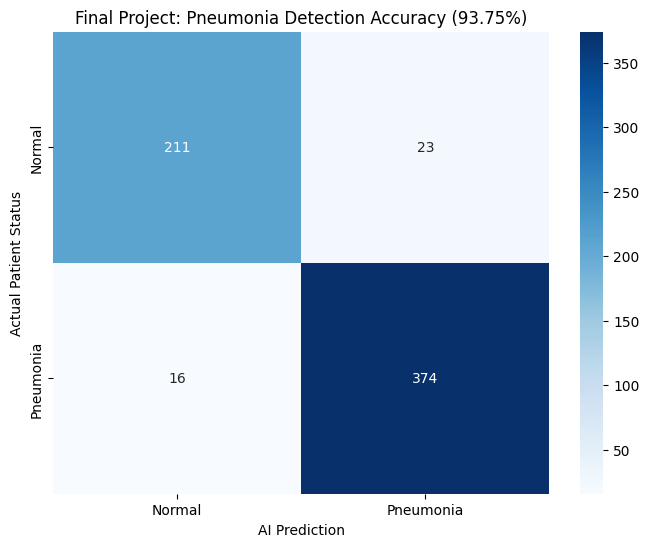

In [20]:
#checking cell
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the matrix
cm = confusion_matrix(test_generator_fixed.classes, y_pred_final)

# 2. Plot it beautifully
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])

plt.title('Final Project: Pneumonia Detection Accuracy (93.75%)')
plt.ylabel('Actual Patient Status')
plt.xlabel('AI Prediction')
plt.show()

In [22]:
import os
import shutil
from IPython.display import FileLink, display

# 1. Search everywhere for your model file
found_path = None
for root, dirs, files in os.walk('/kaggle'):
    if 'pneumonia_detection_final_94pct.keras' in files:
        found_path = os.path.join(root, 'pneumonia_detection_final_94pct.keras')
        print(f"✅ Found it at: {found_path}")
        break

if found_path:
    # 2. To be 100% safe, copy it to the primary working directory
    working_path = '/kaggle/working/pneumonia_detection_final_94pct.keras'
    if found_path != working_path:
        shutil.copy(found_path, working_path)
    
    # 3. Generate the blue download link
    print("Click the link below to download your model:")
    display(FileLink('pneumonia_detection_final_94pct.keras'))
else:
    print("❌ File not found. Re-saving now...")
    model.save('/kaggle/working/pneumonia_detection_final_94pct.keras')
    display(FileLink('pneumonia_detection_final_94pct.keras'))

❌ File not found. Re-saving now...


/kaggle/working/pneumonia_detection_final_94pct.keras